# Color spaces & segmentation

This notebook performs the requested tasks: display BGR vs RGB, HSV channel visualization, HSV masking for red and other fruits, brightness/contrast comparison, and a short reflection. Run cells in order.

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.dpi'] = 100

def show_row(titles, imgs, cmaps=None, figsize=(16,4)):
    if cmaps is None:
        cmaps = [None] * len(imgs)
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)
    if len(imgs) == 1:
        axes = [axes]
    for ax, title, img, cmap in zip(axes, titles, imgs, cmaps):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

base = os.path.join('images')

# 1) Load red_apple.jpg in BGR and display correct (RGB) and raw BGR

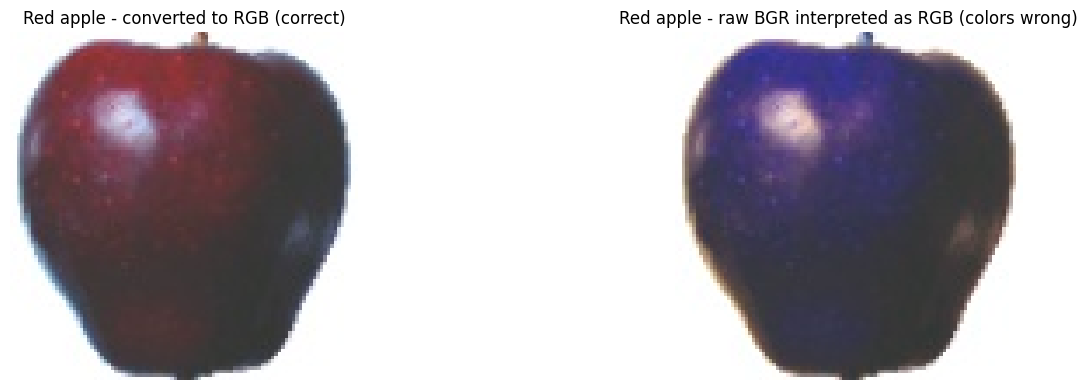

Observation: without conversion BGR appears blue/red swapped.


In [8]:
bgr = cv2.imread(os.path.join('images', 'red_apple.jpg'))
if bgr is None:
    raise FileNotFoundError('red_apple.jpg not found in images/')
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
show_row(
    ['Red apple - converted to RGB (correct)', 'Red apple - raw BGR interpreted as RGB (colors wrong)'],
    [rgb, bgr],
    [None, None]
)
print('Observation: without conversion BGR appears blue/red swapped.')

# 2) Convert to HSV and show H, S, V channels

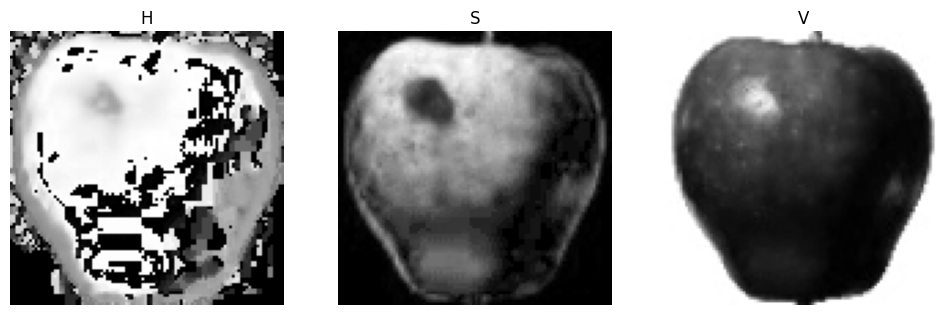

Typically S (saturation) best separates colorful object from white background.


In [9]:
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title('H'); plt.axis('off'); plt.imshow(h, cmap='gray')
plt.subplot(1,3,2); plt.title('S'); plt.axis('off'); plt.imshow(s, cmap='gray')
plt.subplot(1,3,3); plt.title('V'); plt.axis('off'); plt.imshow(v, cmap='gray')
plt.show()
print('Typically S (saturation) best separates colorful object from white background.')

# 3) Masking by color for red (two hue ranges)

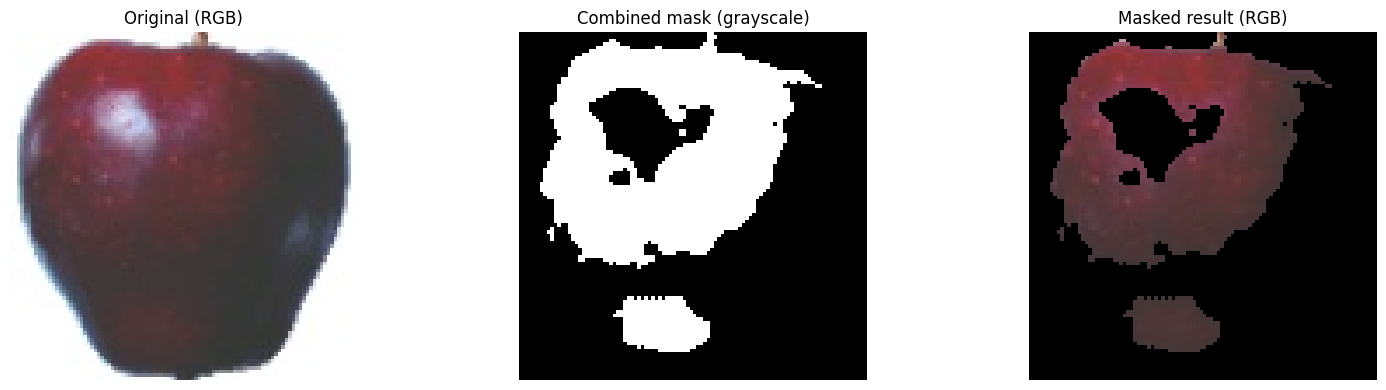

In [10]:
lower1 = np.array([0,50,50])
upper1 = np.array([10,255,255])
lower2 = np.array([170,50,50])
upper2 = np.array([180,255,255])
mask1 = cv2.inRange(hsv, lower1, upper1)
mask2 = cv2.inRange(hsv, lower2, upper2)
mask = cv2.bitwise_or(mask1, mask2)
masked = cv2.bitwise_and(bgr, bgr, mask=mask)
show_row(
    ['Original (RGB)', 'Combined mask (grayscale)', 'Masked result (RGB)'],
    [cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), mask, cv2.cvtColor(masked, cv2.COLOR_BGR2RGB)],

    ['gray' if i == 1 else None for i in range(3)])

# 4) Color table task for other fruits: green apple, banana, lime

In [11]:
files = ['green_apple.jpg','banana.jpg','lime.jpg']
ranges = {
    'green_apple.jpg': ((35,50,30),(85,255,255)),
    'banana.jpg':      ((15,50,50),(35,255,255)),
    'lime.jpg':        ((30,50,50),(75,255,255)),
}
def show_mask_for(path, hsv_min, hsv_max):
    img = cv2.imread(base + path)
    if img is None:
        print(path, 'not found')
        return
    hsv_i = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower = np.array(hsv_min); upper = np.array(hsv_max)
    m = cv2.inRange(hsv_i, lower, upper)
    res = cv2.bitwise_and(img, img, mask=m)
    show_row(
        [f'{path} - original (RGB)', f'{path} - mask', f'{path} - masked'],
        [cv2.cvtColor(img, cv2.COLOR_BGR2RGB), m, cv2.cvtColor(res, cv2.COLOR_BGR2RGB)],
        [None, 'gray', None]
    )

for fname, (mn, mx) in ranges.items():
    show_mask_for(fname, mn, mx)

print("Markdown table (paste into a markdown cell):")
print("Fruit | H_min | H_max | S_min | S_max | V_min | V_max")
print("---|---:|---:|---:|---:|---:|---:")

for fname, (mn, mx) in ranges.items():
    fruit = fname.replace(".jpg", "").replace("_", " ").title()
    print(f"| {fruit} | {mn[0]} | {mx[0]} | {mn[1]} | {mx[1]} | {mn[2]} | {mx[2]} |")

green_apple.jpg not found
banana.jpg not found
lime.jpg not found
Markdown table (paste into a markdown cell):
Fruit | H_min | H_max | S_min | S_max | V_min | V_max
---|---:|---:|---:|---:|---:|---:
| Green Apple | 35 | 85 | 50 | 255 | 30 | 255 |
| Banana | 15 | 35 | 50 | 255 | 50 | 255 |
| Lime | 30 | 75 | 50 | 255 | 50 | 255 |


# 5) Brightness/contrast adjustment for banana and mask reliability

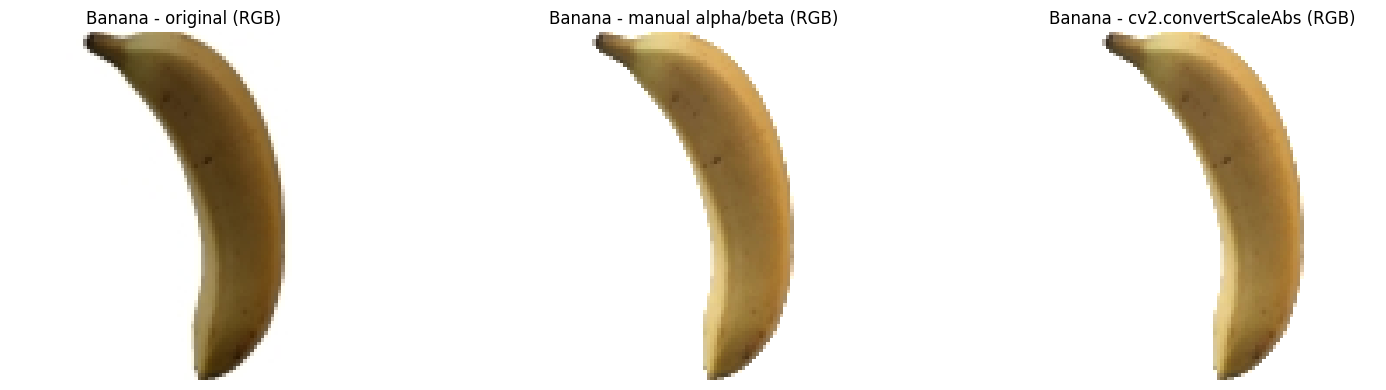

Mask counts (banana) -> original, manual, cv2: 2536 2522 2524


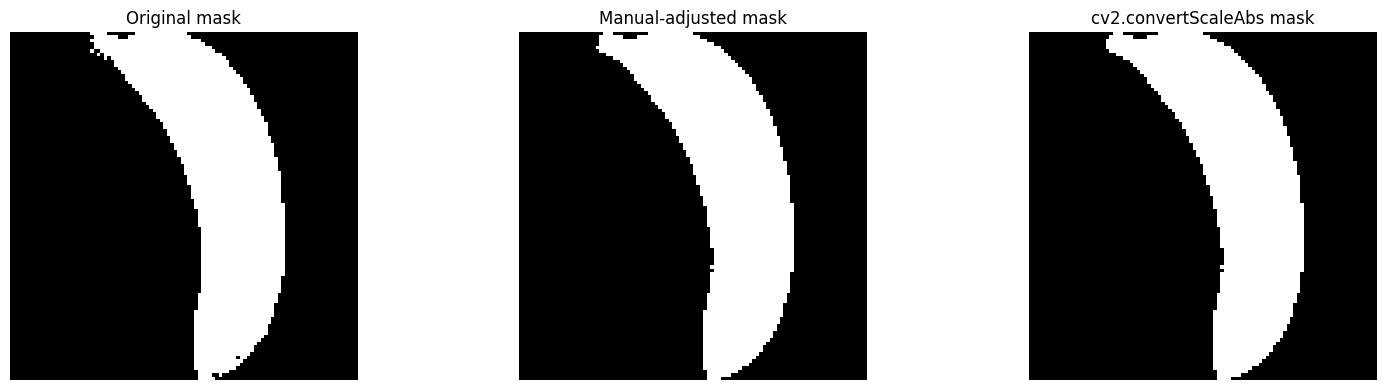

In [12]:
img_b = cv2.imread(os.path.join('images', 'banana.jpg'))
if img_b is None:
    raise FileNotFoundError('banana.jpg not found')
alpha = 1.3; beta = 20
manual = np.clip(alpha * img_b + beta, 0, 255).astype(np.uint8)
cv_scaled = cv2.convertScaleAbs(img_b, alpha=alpha, beta=beta)
show_row(
    ['Banana - original (RGB)', 'Banana - manual alpha/beta (RGB)', 'Banana - cv2.convertScaleAbs (RGB)'],
    [cv2.cvtColor(img_b, cv2.COLOR_BGR2RGB), cv2.cvtColor(manual, cv2.COLOR_BGR2RGB), cv2.cvtColor(cv_scaled, cv2.COLOR_BGR2RGB)],
    [None, None, None]
)
# Compare mask counts using banana range from earlier
bn_range = ranges['banana.jpg']
def mask_count(img_bgr, hsv_min, hsv_max):
    hsv_i = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    m = cv2.inRange(hsv_i, np.array(hsv_min), np.array(hsv_max))
    return cv2.countNonZero(m), m
cnt_orig, m_orig = mask_count(img_b, *bn_range)
cnt_manual, m_manual = mask_count(manual, *bn_range)
cnt_cv, m_cv = mask_count(cv_scaled, *bn_range)
print('Mask counts (banana) -> original, manual, cv2:', cnt_orig, cnt_manual, cnt_cv)
show_row(
    ['Original mask', 'Manual-adjusted mask', 'cv2.convertScaleAbs mask'],
    [m_orig, m_manual, m_cv],
    ['gray', 'gray', 'gray']
)

# 6) Reflection
- HSV separates chromatic information (Hue) from intensity (Value) and purity (Saturation), so thresholds on Hue/Saturation are more robust for segmenting colored objects under varying illumination than raw RGB thresholds.
- It fails when saturation is very low or value is extreme: very dark or nearly white objects have unstable or meaningless Hue. Examples: very dark purple grapes or blueberries — low V and S make Hue unreliable.